In [ ]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
from rapidfuzz import fuzz
from rapidfuzz import distance
from src.similarity_matrix import (
    create_sim_m_heatmap,
    create_sim_m,
)

## Load used data

Moving record formats metadata

In [2]:
book_migration_directions = pd.read_csv(
    "outputs/csv/book_migration_direction_info.csv"
)

In [3]:
with open("outputs/json/book_ids.json", "r") as fp:
    book_id_to_info = json.load(fp)

## Duplicate filtering

In [169]:
jsonls = tuple(
    Path("outputs/json/all_migration_events_parish_splits").glob("*.jsonl")
)
threshold = 0.8

for parish_jsonl in tqdm(jsonls):
    parish_df = pd.read_json(parish_jsonl, lines=True)
    parish_df["duplicate"] = False
    parish_df["duplicate_of"] = None
    parish_df["is_ap"] = parish_df["book_source"].str.contains("ap")
    p_id = parish_df.loc[0, "parish_id"]

    for (year, direction), group in parish_df.groupby(
        ["year_prediction", "in/out"]
    ):
        events_ap = group[group["is_ap"]]
        events_other = group[~group["is_ap"]]

        other_sizes = (
            events_other.groupby("book_source")
            .size()
            .sort_values(ascending=False)
        )

        source_order = (["__ap__"] if not events_ap.empty else []) + list(
            other_sizes.index
        )

        source_frames = {"__ap__": events_ap}
        source_frames.update(
            {
                src: events_other[events_other["book_source"] == src]
                for src in other_sizes.index
            }
        )

        for i, ref_src in enumerate(source_order[:-1]):
            reference = source_frames[ref_src]
            if reference.empty:
                continue

            for cand_src in source_order[i + 1 :]:
                candidate = source_frames[cand_src]
                if candidate.empty:
                    continue

                sim_m = (
                    create_sim_m(
                        reference["row_data"].to_list(),
                        candidate["row_data"].to_list(),
                        distance.Levenshtein.normalized_similarity,
                        join_char="",
                        n_workers=-1,
                    )[0]
                    * 100
                )

                duplicates = np.where(sim_m >= threshold)

                duplicate_pages = candidate.iloc[duplicates[1]].index
                parish_df.loc[
                    parish_df.index.isin(duplicate_pages)
                    & (parish_df["book_source"] == cand_src),
                    "duplicate",
                ] = True

                parish_df.loc[
                    candidate.iloc[duplicates[1]].index, "duplicate_of"
                ] = reference.iloc[duplicates[0]].index

    with open(
        f"outputs/json/all_migration_events_parish_splits_duplicate_info/{p_id}_migration_events.jsonl",
        "w",
    ) as fp:
        rows_to_write = []
        for line in parish_df[
            [
                "row_data",
                "row_columns",
                "year_prediction",
                "book_year_start",
                "book_year_end",
                "duplicate", "duplicate_of",
                "page_n",
                "file_row",
                "in/out",
                "side",
                "parish_id",
                "book_id",
                "print_type",
                "book_source",
                "file_path",
            ]
        ].to_dict(orient="records"):
            rows_to_write.append(json.dumps(line, ensure_ascii=False) + "\n")

        fp.writelines(rows_to_write)

  0%|          | 0/468 [00:00<?, ?it/s]

## Results

In [127]:
def migration_duplicate_filtering_before_after_counts(df, years, in_out_filter:list=None):
    year_mask = df["year_prediction"].isin(range(*years))
    if in_out_filter == None:
        df_years = df[year_mask]
    else:
        df_years = df[year_mask & (df["in/out"].isin(in_out_filter))]

    counts_before = df_years.groupby("book_id").size()
    counts_after = df_years[~df_years["duplicate"]].groupby("book_id").size()

    counts = {}
    for book_id in counts_before.index:
        before = counts_before[book_id]
        after = counts_after.get(book_id, 0)
        counts[book_id] = {
            "before": int(before),
            "after": int(after)
        }

    return counts

In [149]:
def plot_migration_similarity_heatmaps(df, parish, years, in_out_filter:list=None):
    year_mask = df["year_prediction"].isin(range(*years))
    if in_out_filter == None:
        df_years = df[year_mask]
    else:
        df_years = df[year_mask & (df["in/out"].isin(in_out_filter))]
    
    pages = df_years.groupby(["book_id", "page_n"], sort=False)

    page_keys = list(pages.groups.keys())
    page_sort_key = [
        (pages.get_group(k)["year_prediction"].min(), k[1]) for k in page_keys
    ]
    page_keys = [k for _, k in sorted(zip(page_sort_key, page_keys))]

    row_data_per_page = [",".join(pages.get_group(k)["row_data"].sum()) for k in page_keys]
    duplicate_per_page = [pages.get_group(k)["duplicate"].any() for k in page_keys]

    sim_m = create_sim_m(
        row_data_per_page, row_data_per_page,
        fuzz.ratio, join_char="", n_workers=-1
    )[0]

    sim_m_zeroed = sim_m.copy()
    dup_idx = [i for i, is_dup in enumerate(duplicate_per_page) if is_dup]
    sim_m_zeroed[dup_idx, :] = 0
    sim_m_zeroed[:, dup_idx] = 0

    fig, axs = plt.subplots(1, 3, figsize=(30, 10))
    fig.suptitle(f"{parish}, year range: {years}")

    create_sim_m_heatmap(
        sim_m, xlabel="", ylabel="", ax=axs[0], cbar=False,
        vmin=0, vmax=1,
    )
    axs[0].set_title("No duplicate filtering")

    create_sim_m_heatmap(
        sim_m, xlabel="", ylabel="", ax=axs[1], cbar=False,
        vmin=0, vmax=1, cmap=sns.cm.crest_r
    )
    axs[1].set_title("Duplicate filtering")

    for i, is_dup in enumerate(duplicate_per_page):
        if is_dup:
            axs[1].axhspan(i, i + 1, color="red", alpha=0.3, zorder=2, lw=0)
            axs[1].axvspan(i, i + 1, color="red", alpha=0.3, zorder=2, lw=0)

    create_sim_m_heatmap(
        sim_m_zeroed, xlabel="", ylabel="", ax=axs[2], cbar=False,
        vmin=0, vmax=1
    )
    axs[2].set_title("Duplicate areas zeroed")

    return fig, axs

In [150]:
def plot_book_year_event_heatmap(df, parish, years):
    year_mask = df["year_prediction"].isin(range(*years))
    df_years = df[year_mask]

    year_range = list(range(*years))
    row_keys = sorted(df_years[["book_id", "in/out"]].drop_duplicates().itertuples(index=False, name=None))

    row_idx = {k: i for i, k in enumerate(row_keys)}
    year_idx = {y: i for i, y in enumerate(year_range)}

    count_matrix = np.full((len(row_keys), len(year_range)), np.nan)
    dup_matrix = np.zeros((len(row_keys), len(year_range)), dtype=bool)

    grouped = df_years.groupby(["book_id", "in/out", "year_prediction"])
    counts = grouped.size()
    dup_flags = grouped["duplicate"].any()

    for (book_id, in_out, year), count in counts.items():
        if year in year_idx:
            count_matrix[row_idx[(book_id, in_out)], year_idx[year]] = count

    for (book_id, in_out, year), is_dup in dup_flags.items():
        if year in year_idx and is_dup:
            dup_matrix[row_idx[(book_id, in_out)], year_idx[year]] = True

    fig, ax = plt.subplots(
        figsize=(30, 5)
    )
    fig.suptitle(f"{parish}, year range: {years}")

    masked = np.ma.masked_invalid(count_matrix)
    mesh = ax.pcolormesh(masked, cmap="viridis", edgecolors="grey", linewidth=0.5)
    fig.colorbar(mesh, ax=ax, label="Event count")

    for i in range(len(row_keys)):
        for j in range(len(year_range)):
            if dup_matrix[i, j]:
                ax.add_patch(
                    plt.Rectangle(
                        (j, i), 1, 1, fill=False, hatch="//",
                        edgecolor="red", linewidth=1.5
                    )
                )

    ax.set_xticks(np.arange(len(year_range)) + 0.5)
    ax.set_xticklabels(year_range, rotation=90)
    ax.set_yticks(np.arange(len(row_keys)) + 0.5)
    ax.set_yticklabels([f"{book_id} ({in_out})" for book_id, in_out in row_keys])
    ax.set_xlabel("Year")
    ax.set_ylabel("book_id (in/out)")
    ax.set_aspect("equal")
    ax.invert_yaxis()

    return fig, ax

In [151]:
def plot_non_duplicate_migration_histogram(df, in_out_filter: list = None):
    year_non_zero_mask = df["year_prediction"] != 0
    if in_out_filter == None:
        df_filtered = df[
            ~df["duplicate"]
            & year_non_zero_mask
        ]["year_prediction"]
    else:
        df_filtered = df[
            ~df["duplicate"]
            & (df["in/out"].isin(in_out_filter))
            & year_non_zero_mask
        ]["year_prediction"]

    year_range = range(df_filtered.min(), df_filtered.max() + 1)

    fig, ax = plt.subplots(figsize=(30, 5))
    sns.histplot(df_filtered, bins=year_range)
    ax.set_xticks(year_range)
    ax.set_xticklabels(year_range, rotation=90)

### Examining specific years from a parish

{7730: {'before': 2512, 'after': 792}, 41928: {'before': 6004, 'after': 6004}}

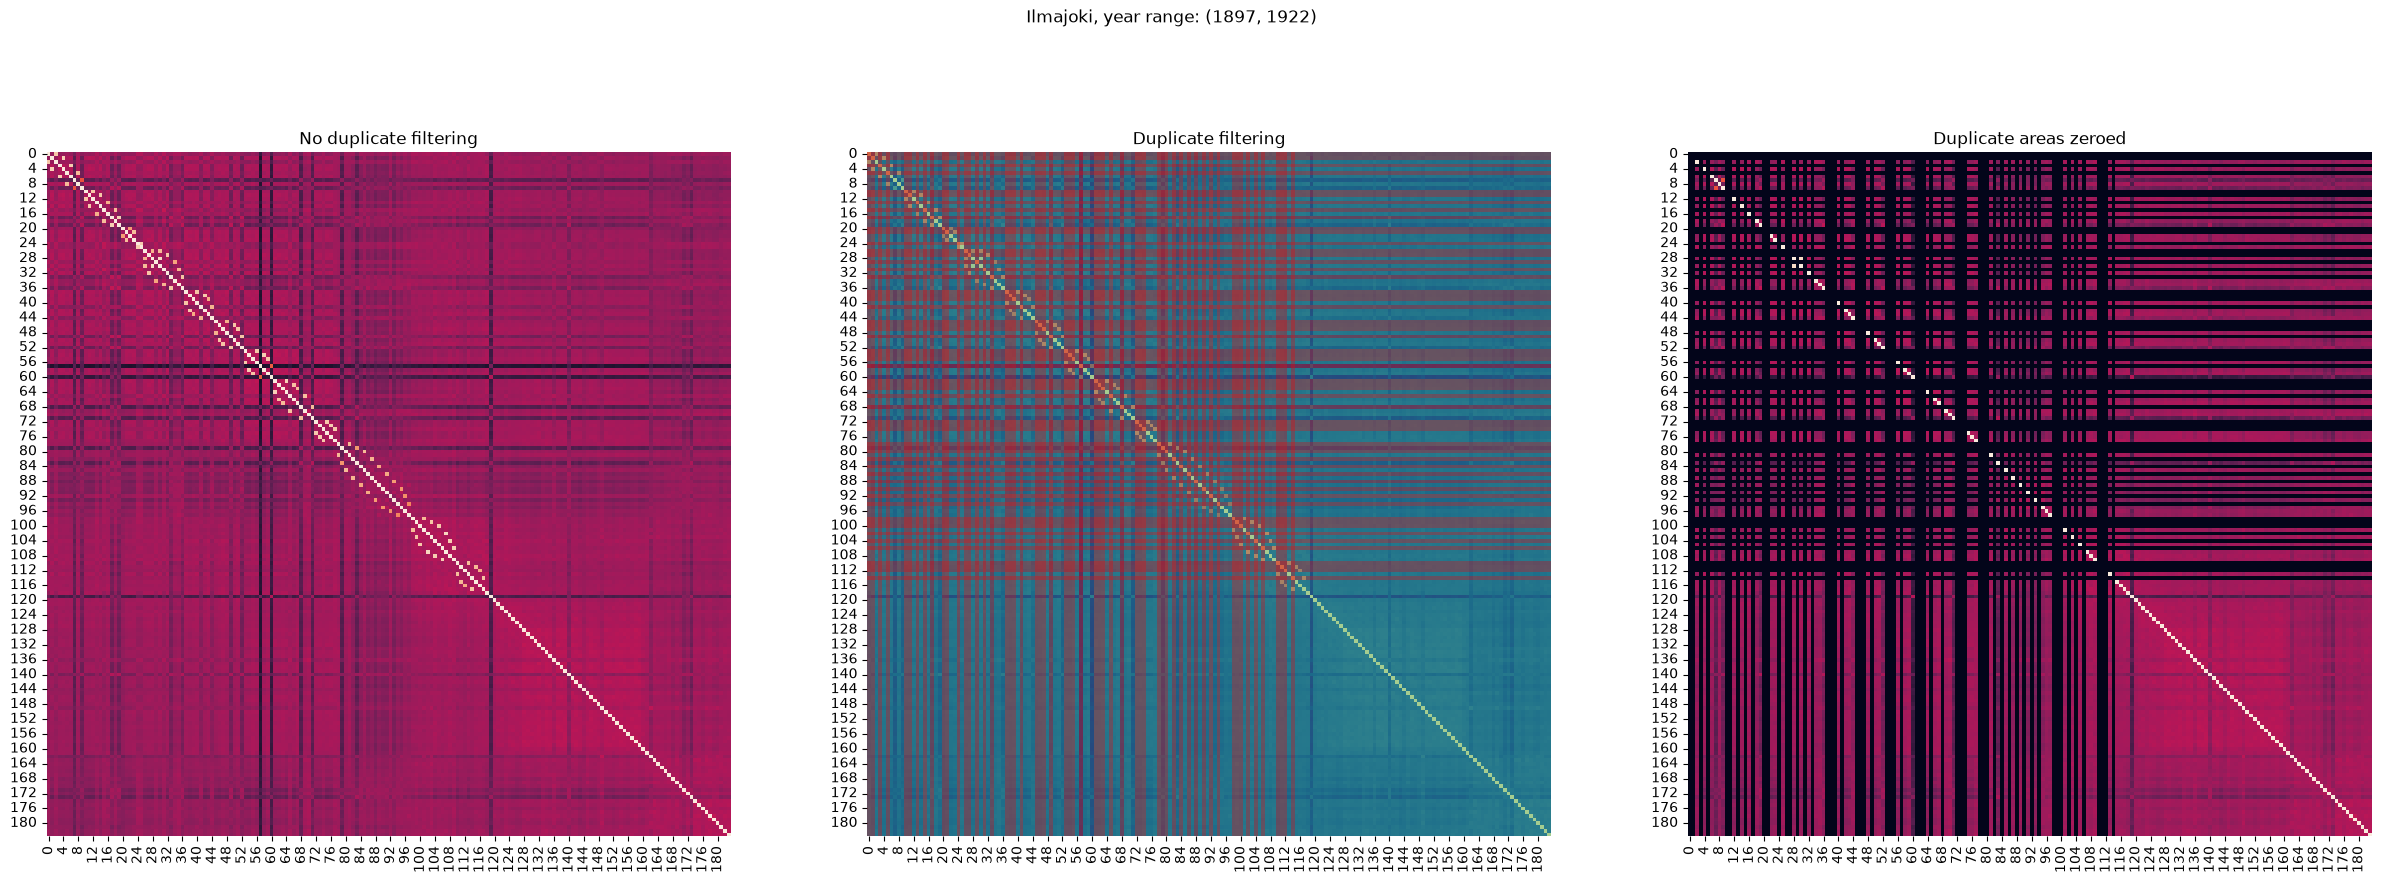

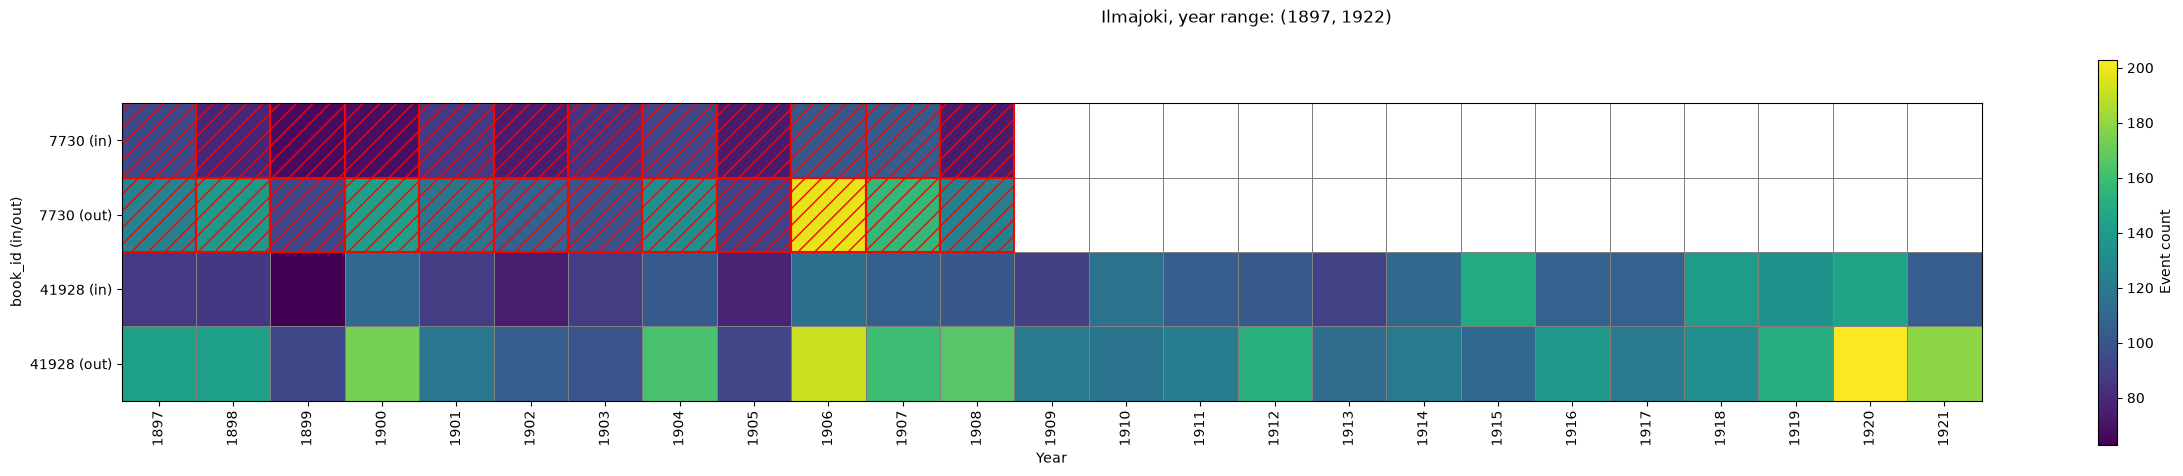

In [152]:
df_ilmajoki = pd.read_json(
    f"outputs/json/all_migration_events_parish_splits_duplicate_info/115_migration_events.jsonl",
    lines=True
)
fig, axs = plot_migration_similarity_heatmaps(df_ilmajoki, "Ilmajoki", (1897, 1922))
fig, axs = plot_book_year_event_heatmap(df_ilmajoki, "Ilmajoki", (1897, 1922))
migration_duplicate_filtering_before_after_counts(df_ilmajoki, (1897, 1922))

{24285: {'before': 344, 'after': 344},
 24286: {'before': 892, 'after': 892},
 24287: {'before': 1434, 'after': 1434},
 24288: {'before': 4387, 'after': 4387},
 24289: {'before': 607, 'after': 607},
 24290: {'before': 2669, 'after': 2669},
 24291: {'before': 4071, 'after': 4071}}

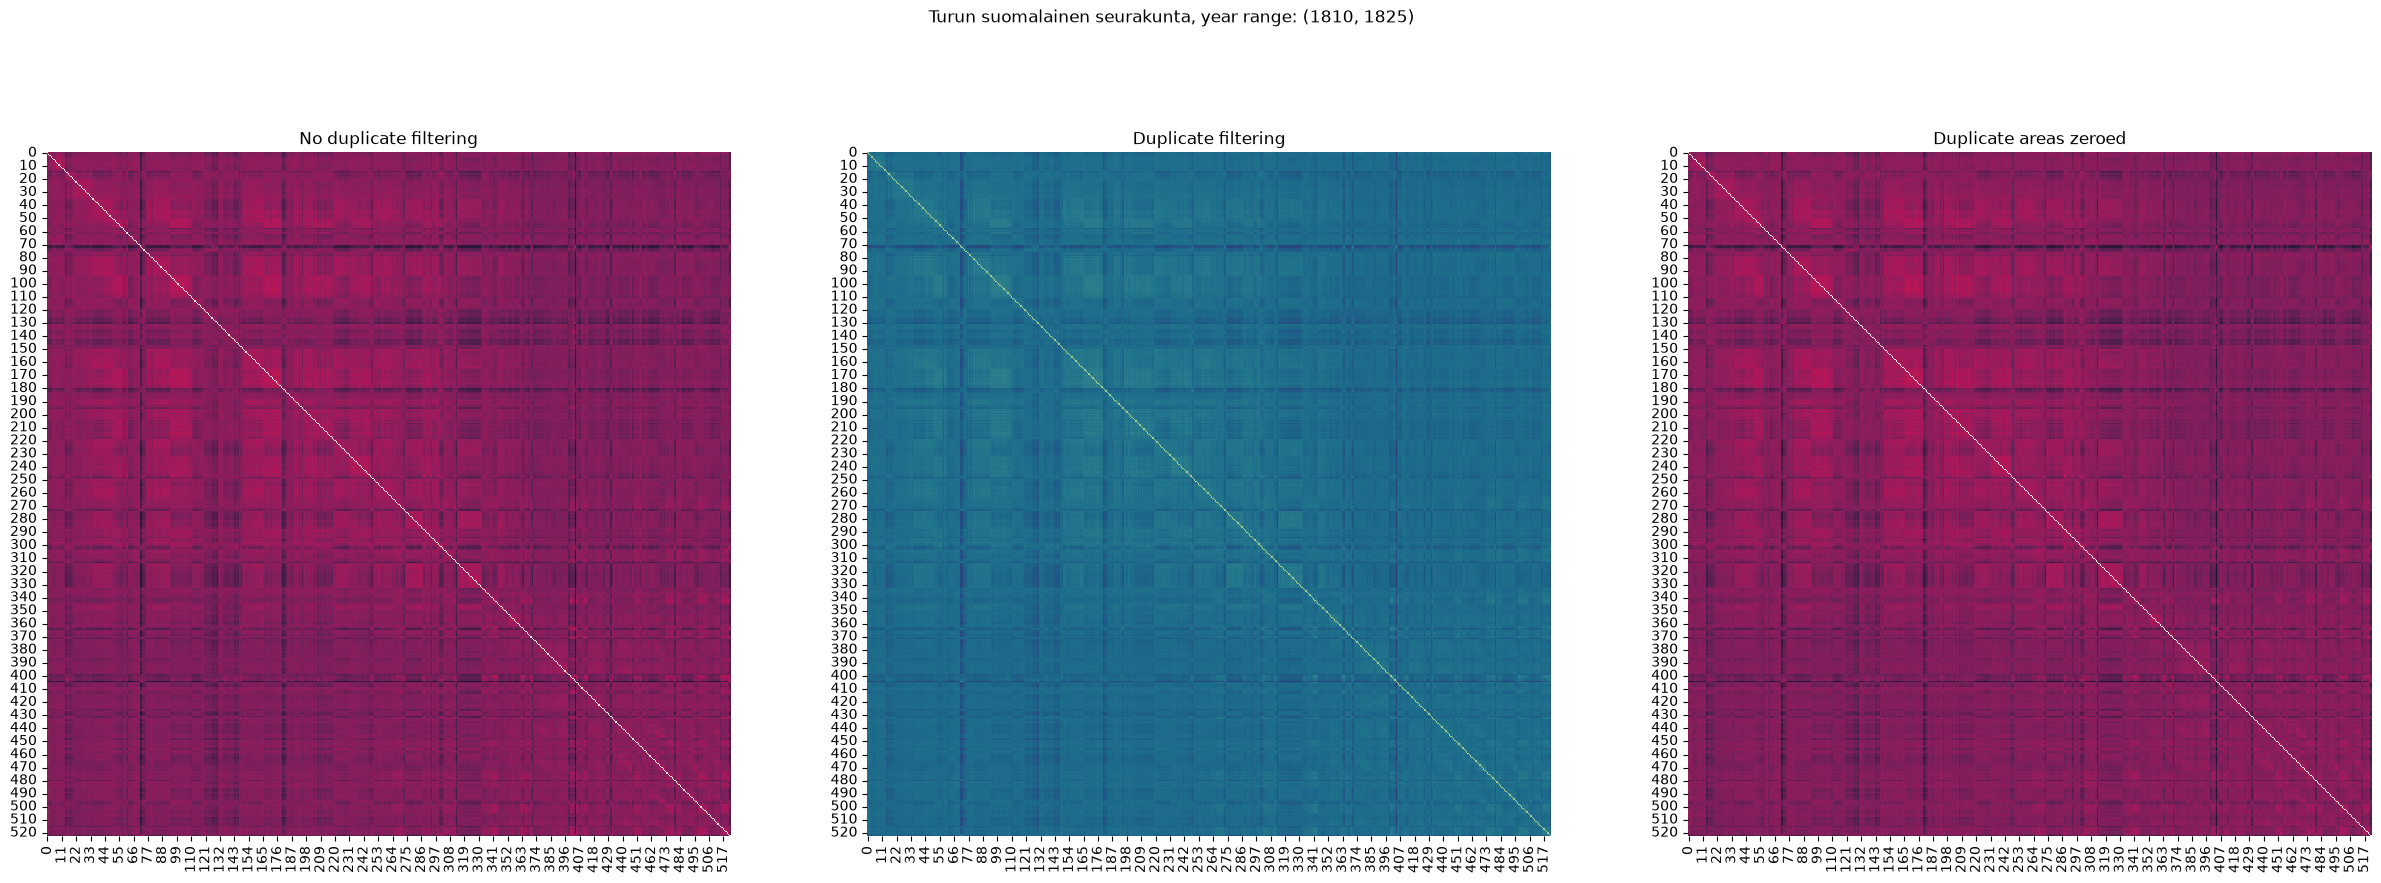

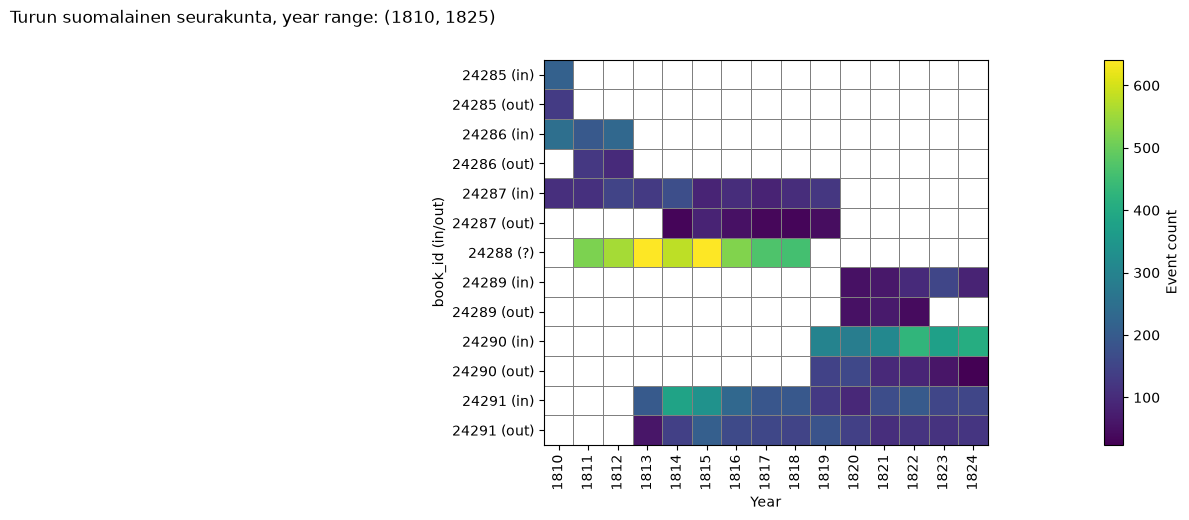

In [153]:
df_turun_suom = pd.read_json(
    f"outputs/json/all_migration_events_parish_splits_duplicate_info/569_migration_events.jsonl",
    lines=True
)
fig, axs = plot_migration_similarity_heatmaps(df_turun_suom, "Turun suomalainen seurakunta", (1810, 1825))
fig, axs = plot_book_year_event_heatmap(df_turun_suom, "Turun suomalainen seurakunta", (1810, 1825))
migration_duplicate_filtering_before_after_counts(df_turun_suom, (1810, 1825))

{19110: {'before': 1639, 'after': 1639},
 31351: {'before': 1923, 'after': 1923}}

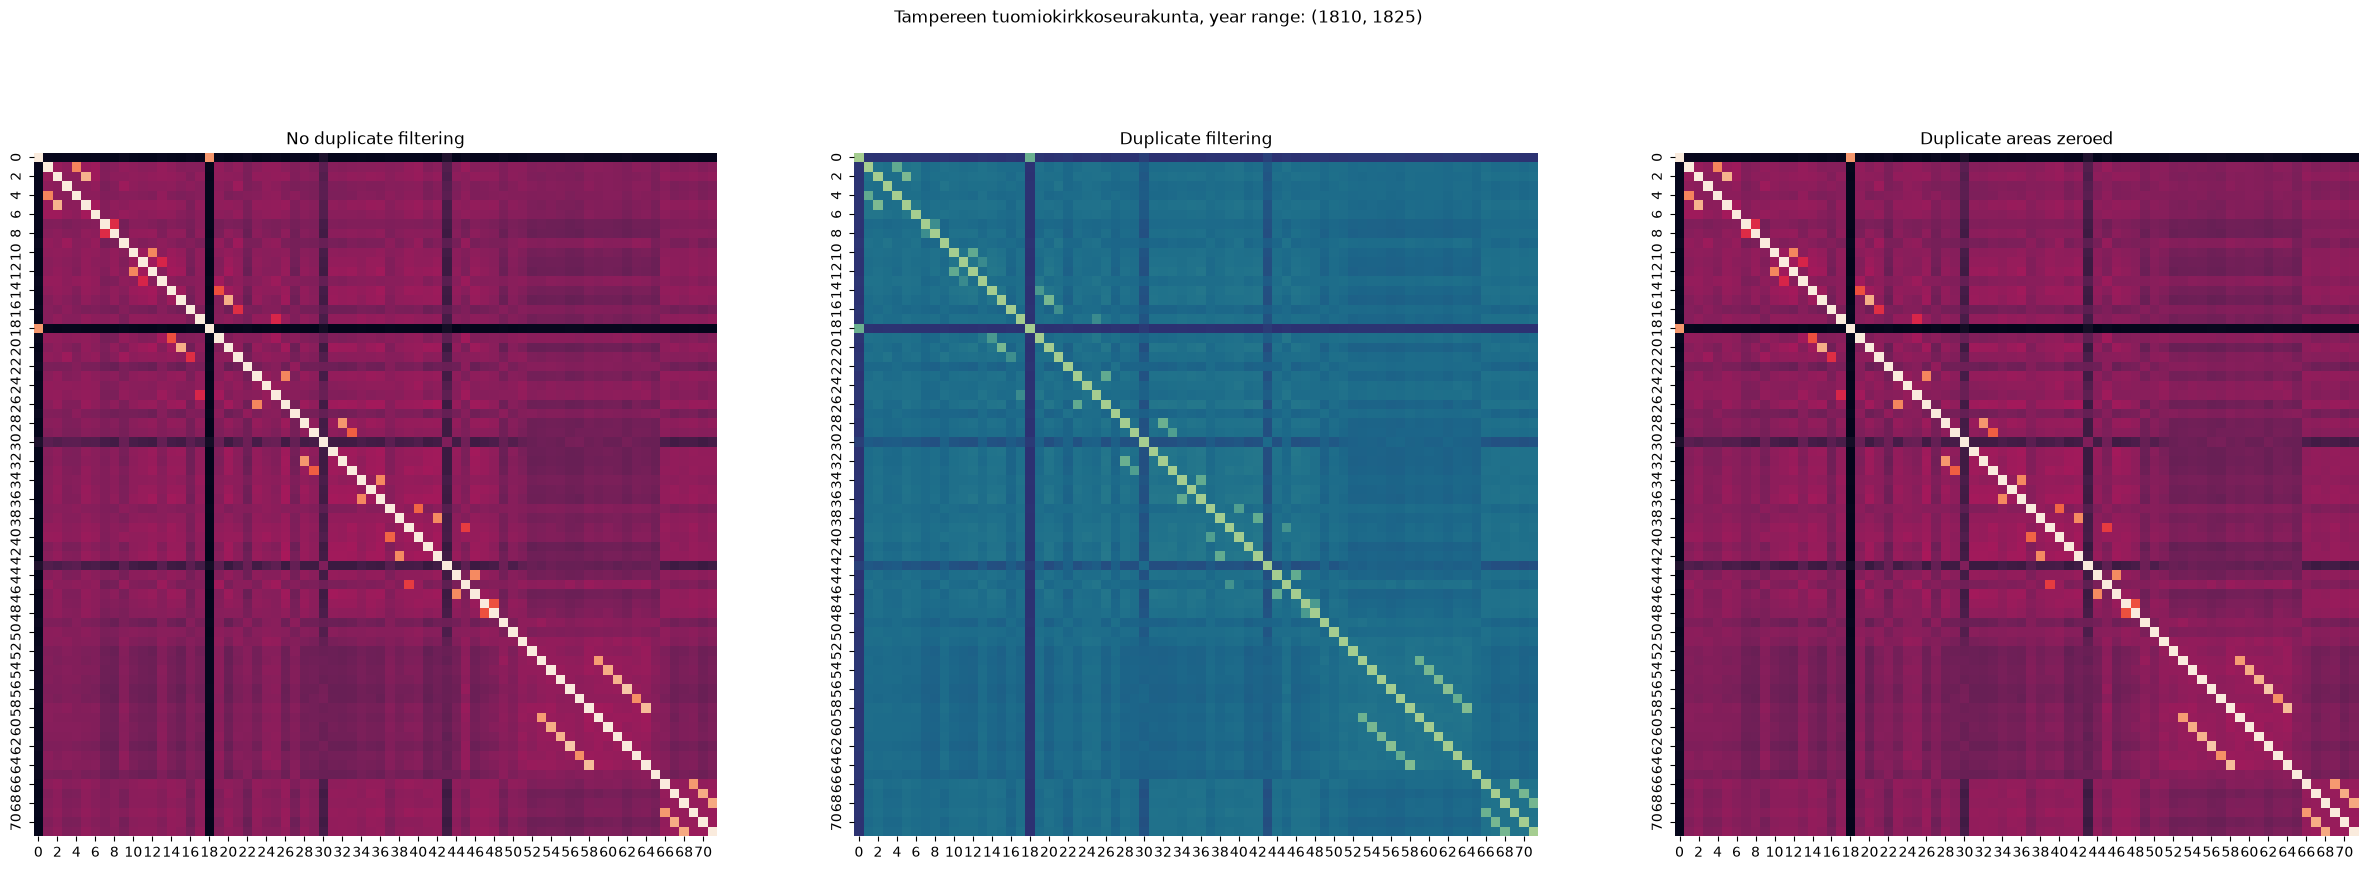

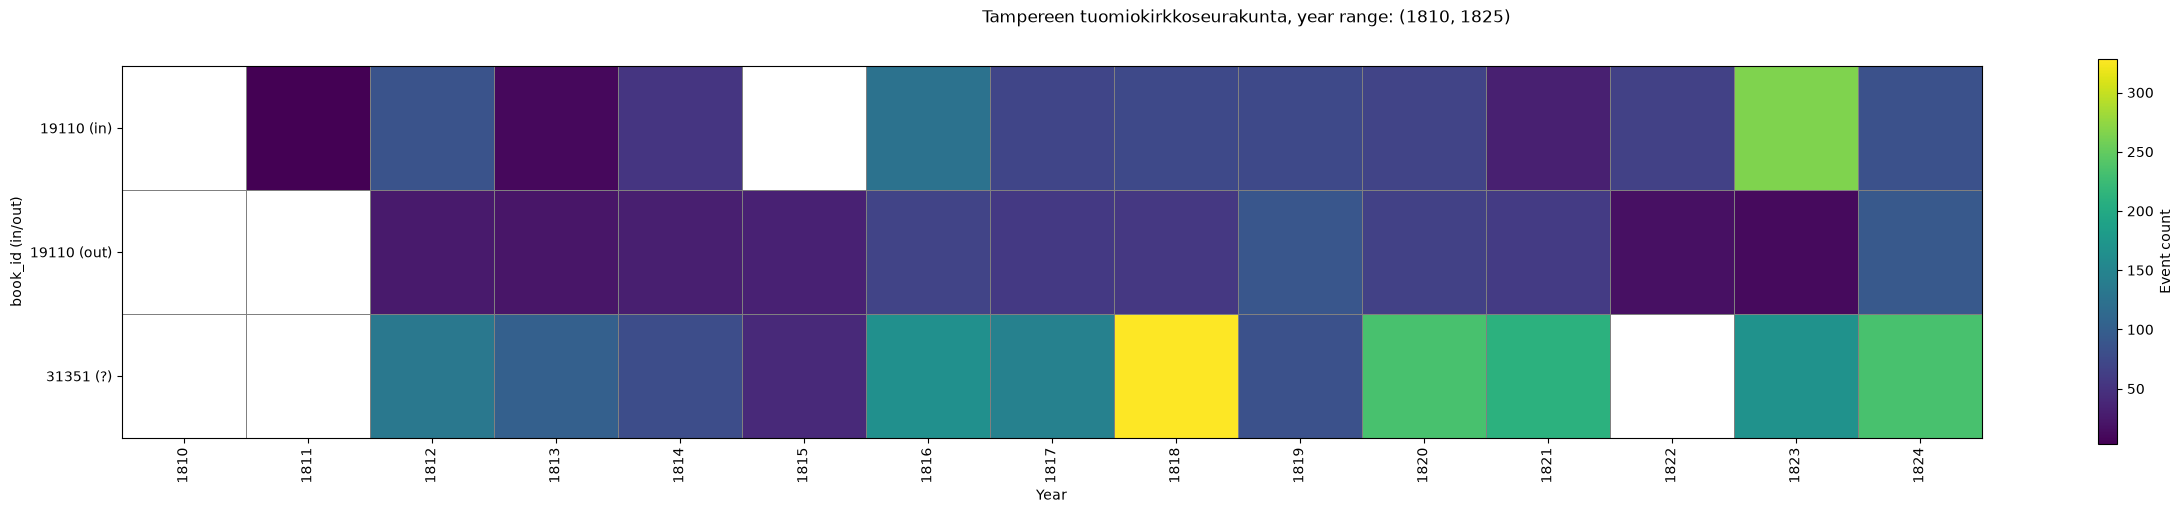

In [154]:
df_tampereen_tuom = pd.read_json(
    f"outputs/json/all_migration_events_parish_splits_duplicate_info/543_migration_events.jsonl",
    lines=True
)
fig, axs = plot_migration_similarity_heatmaps(df_tampereen_tuom, "Tampereen tuomiokirkkoseurakunta", (1810, 1825))
fig, axs = plot_book_year_event_heatmap(df_tampereen_tuom, "Tampereen tuomiokirkkoseurakunta", (1810, 1825))
migration_duplicate_filtering_before_after_counts(df_tampereen_tuom, (1810, 1825))

### Examining whole history of some parishes

{7667: {'before': 3067, 'after': 3067},
 7668: {'before': 503, 'after': 503},
 7669: {'before': 7261, 'after': 7261},
 7670: {'before': 2358, 'after': 2358},
 7730: {'before': 2512, 'after': 792},
 41928: {'before': 6004, 'after': 6004}}

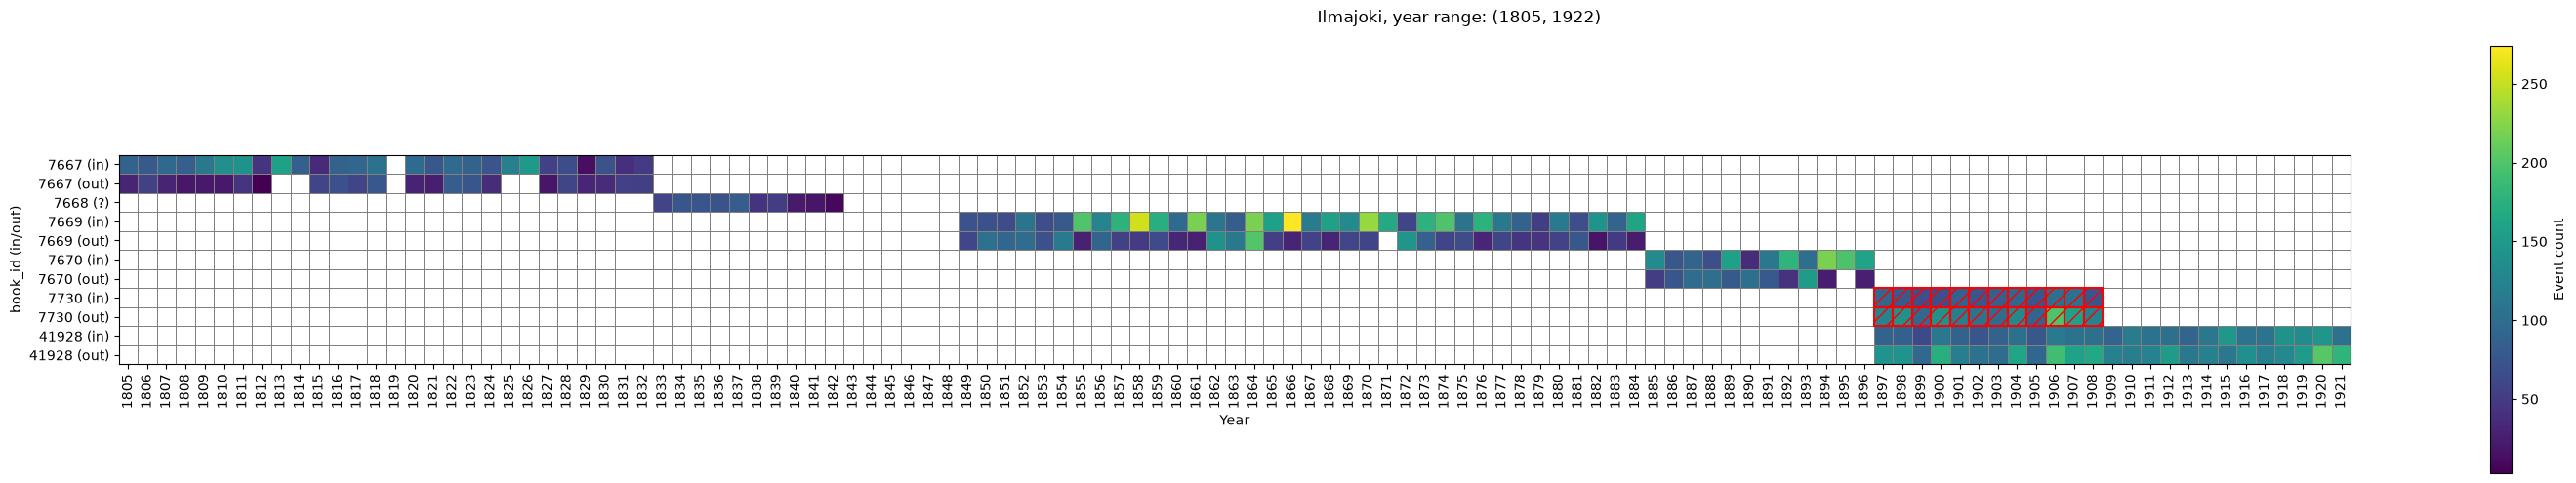

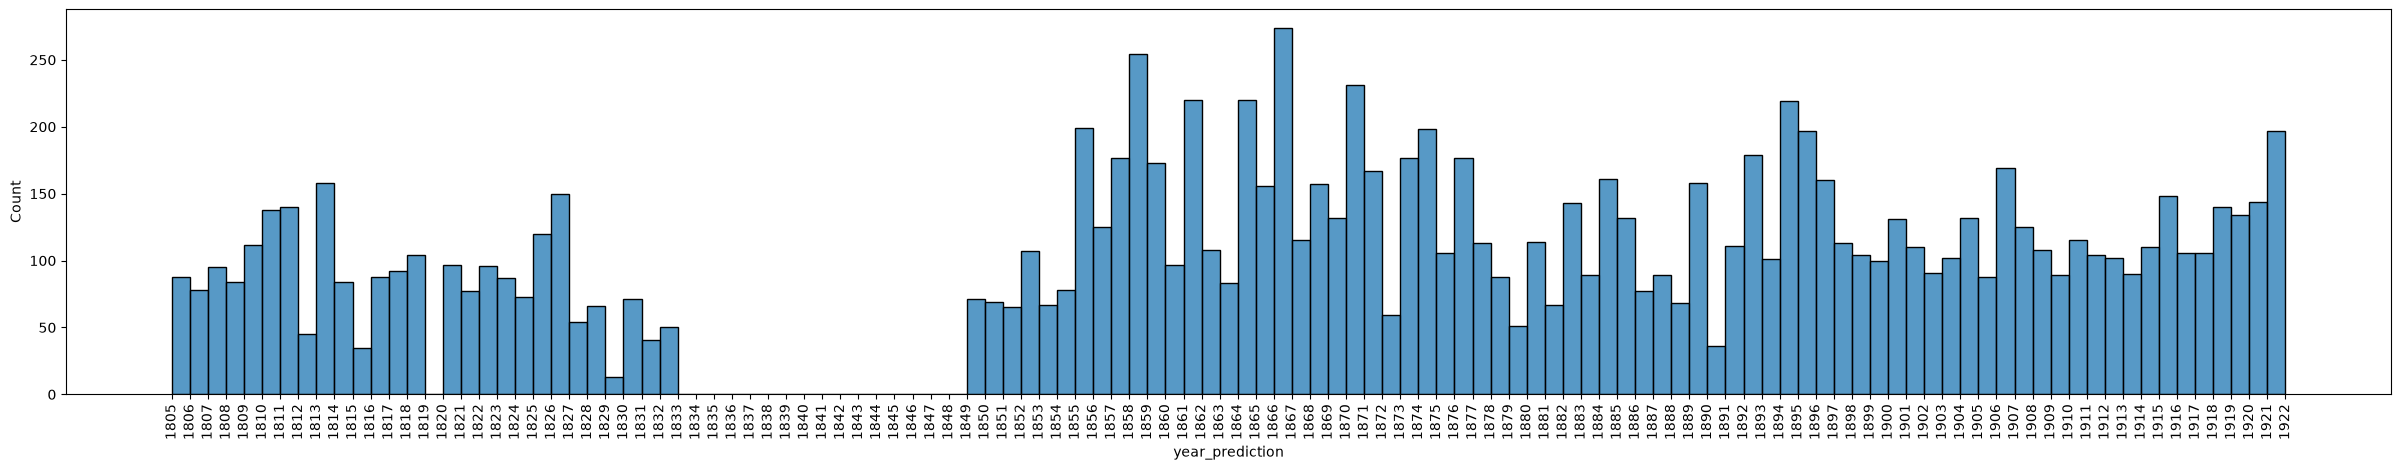

In [155]:
display(migration_duplicate_filtering_before_after_counts(df_ilmajoki, (1807, 1922)))
fig, axs = plot_book_year_event_heatmap(df_ilmajoki, "Ilmajoki", (1805, 1922))
plot_non_duplicate_migration_histogram(df_ilmajoki, ["in"])
fig.tight_layout()

{16506: {'before': 3066, 'after': 2121},
 16507: {'before': 200, 'after': 79},
 16508: {'before': 2422, 'after': 1672},
 16509: {'before': 312, 'after': 288},
 16510: {'before': 168, 'after': 62},
 16511: {'before': 6796, 'after': 2001},
 25358: {'before': 3632, 'after': 3632},
 25359: {'before': 2355, 'after': 2355},
 25360: {'before': 734, 'after': 734},
 25361: {'before': 6707, 'after': 6707},
 25362: {'before': 3420, 'after': 3420},
 25363: {'before': 2882, 'after': 2882},
 43145: {'before': 1472, 'after': 1472}}

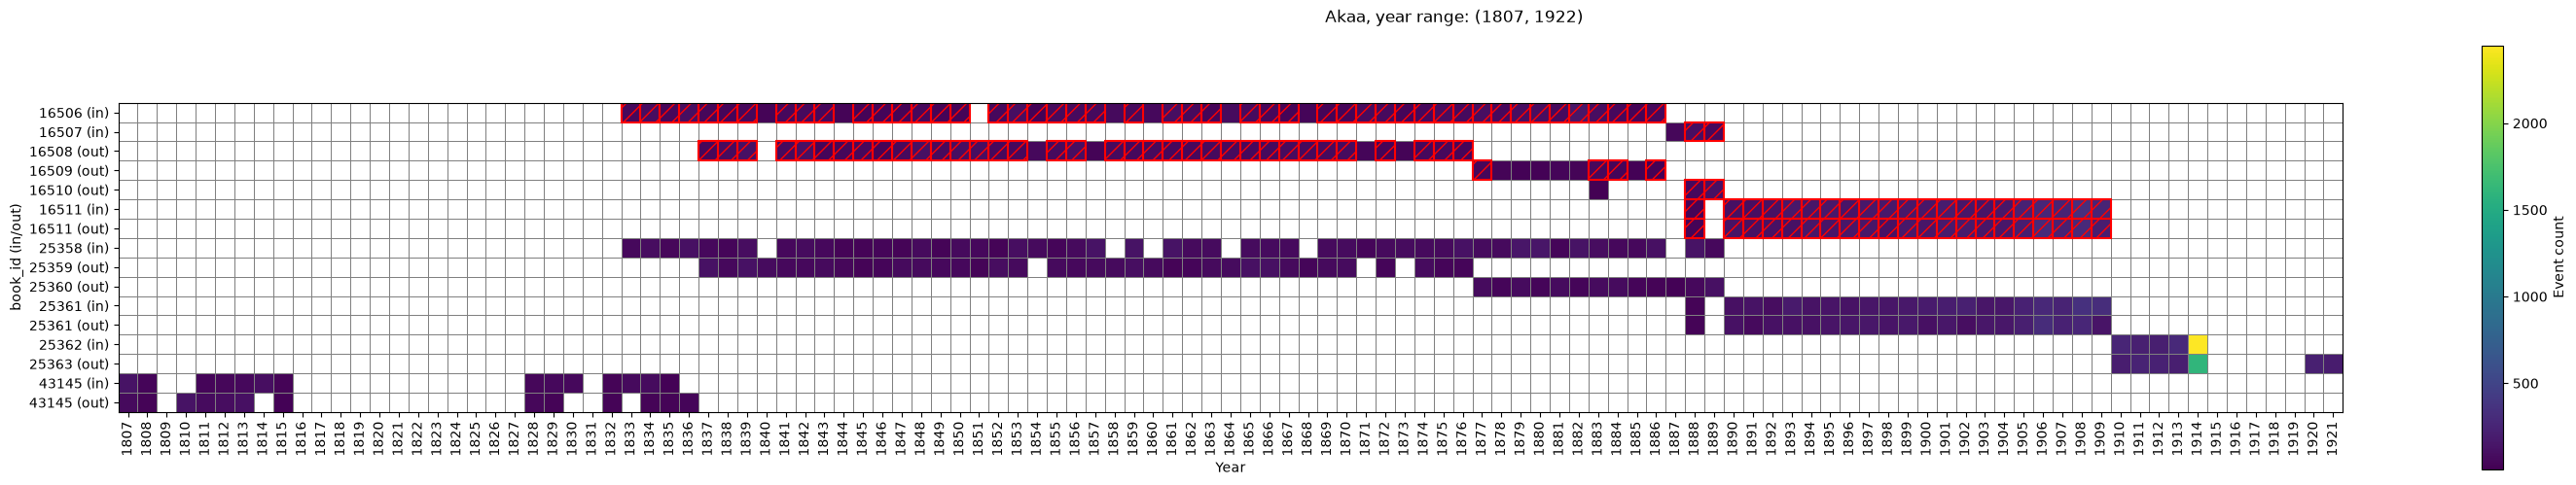

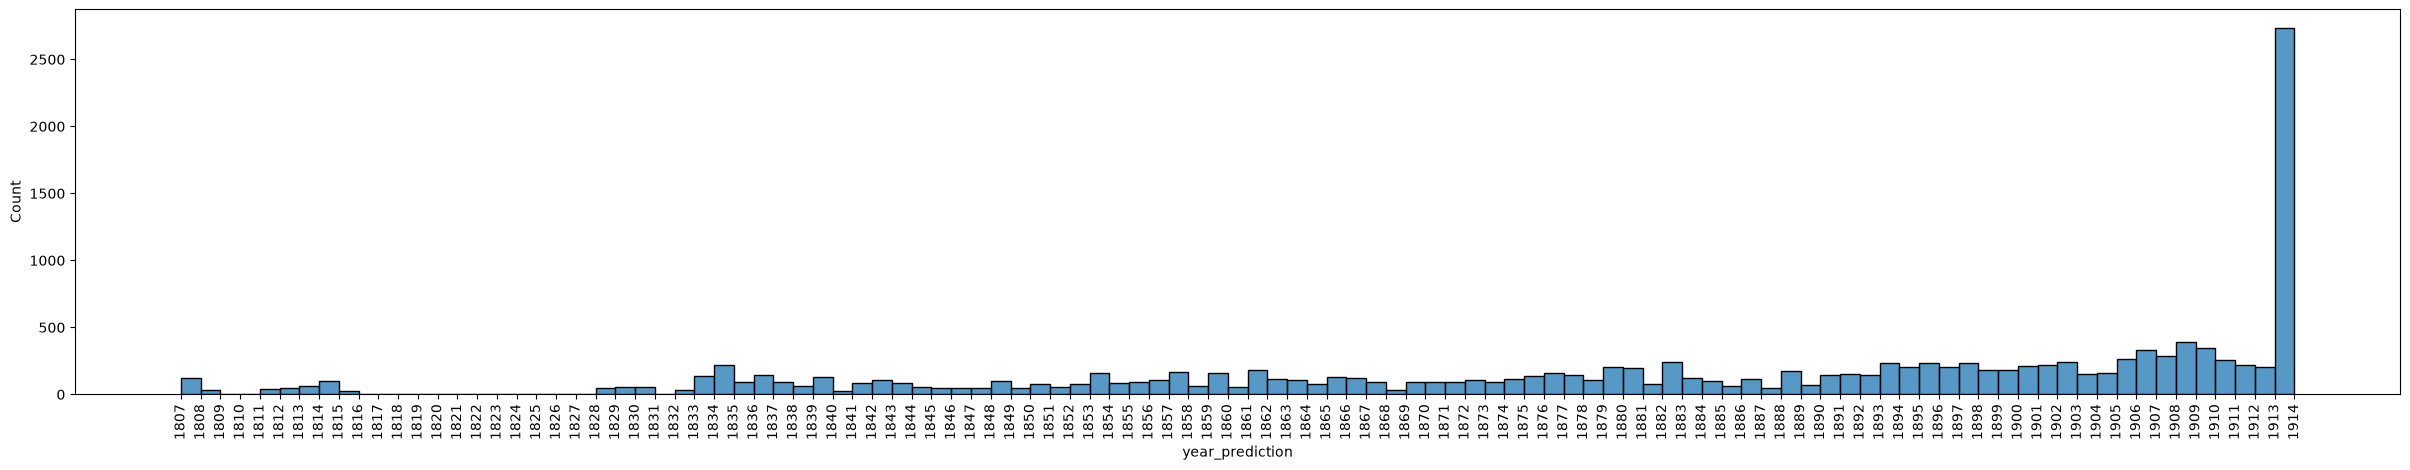

In [156]:
df_akaa = pd.read_json(
    f"outputs/json/all_migration_events_parish_splits_duplicate_info/3_migration_events.jsonl",
    lines=True
)
display(migration_duplicate_filtering_before_after_counts(df_akaa, (1807, 1922)))
fig, axs = plot_book_year_event_heatmap(df_akaa, "Akaa", (1807, 1922))
plot_non_duplicate_migration_histogram(df_akaa, ["in"])
fig.tight_layout()

{6399: {'before': 374, 'after': 351},
 24794: {'before': 1191, 'after': 1189},
 24795: {'before': 180, 'after': 180}}

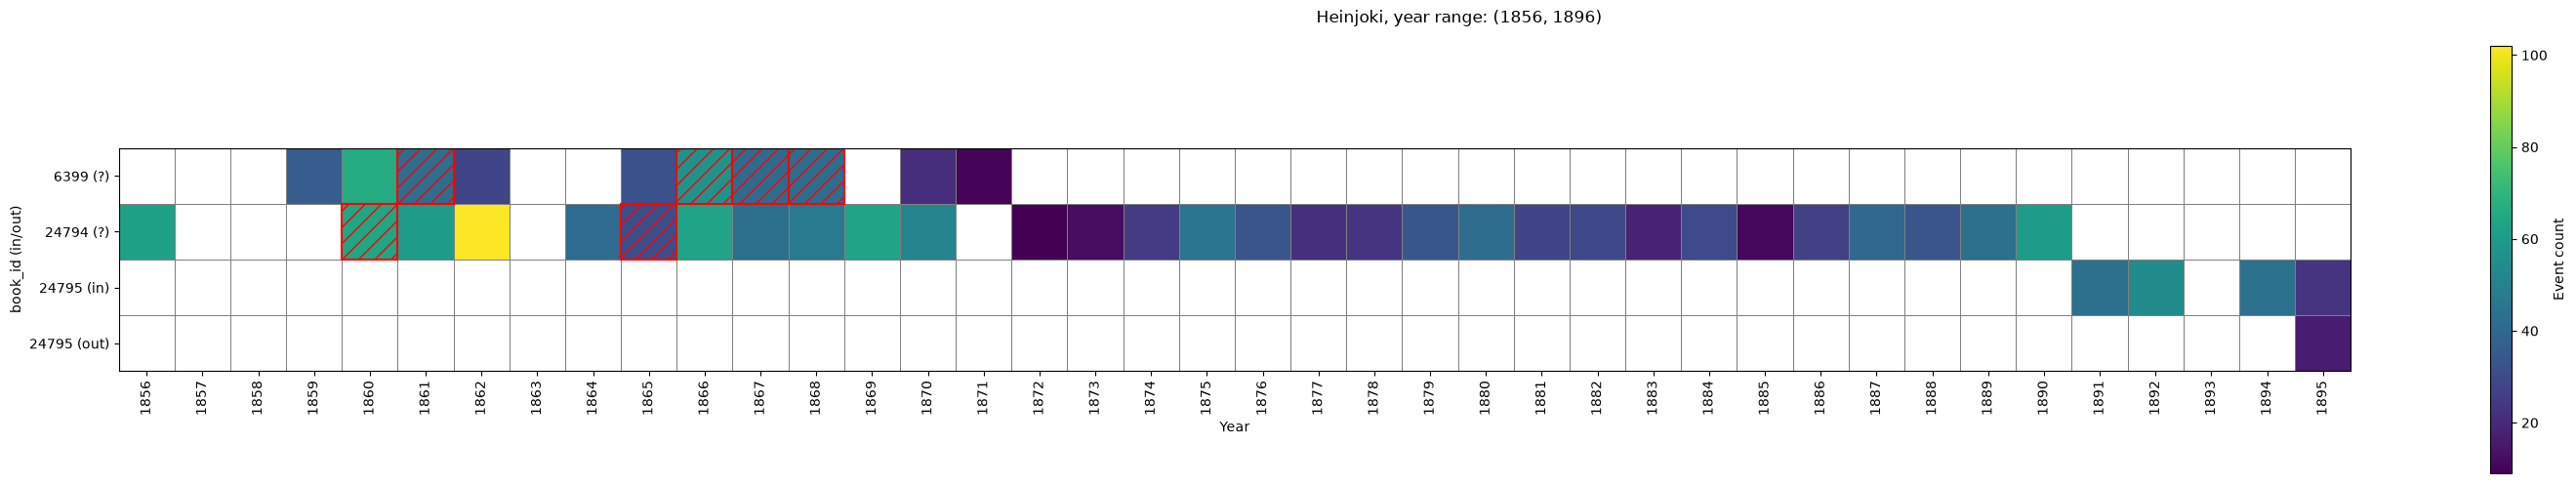

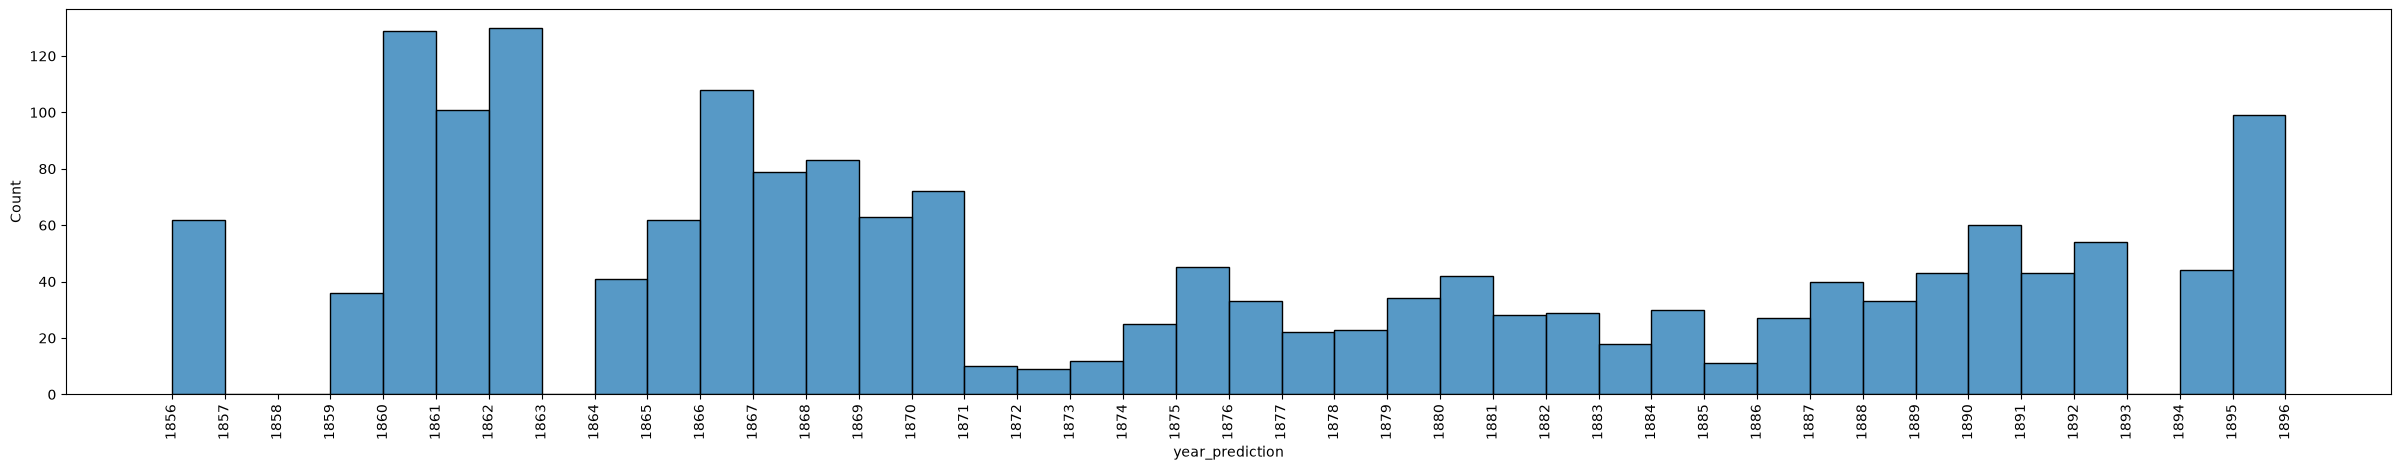

In [157]:
df_heinjoki = pd.read_json(
    f"outputs/json/all_migration_events_parish_splits_duplicate_info/68_migration_events.jsonl",
    lines=True
)

display(migration_duplicate_filtering_before_after_counts(df_heinjoki, (1856, 1896)))
fig, axs = plot_book_year_event_heatmap(df_heinjoki, "Heinjoki", (1856, 1896))
plot_non_duplicate_migration_histogram(df_heinjoki)
fig.tight_layout()

{26262: {'before': 399, 'after': 399},
 26263: {'before': 754, 'after': 754},
 26264: {'before': 683, 'after': 517},
 26265: {'before': 298, 'after': 298},
 26266: {'before': 457, 'after': 457},
 26267: {'before': 369, 'after': 369},
 43239: {'before': 731, 'after': 731},
 43240: {'before': 2068, 'after': 2068},
 43241: {'before': 1150, 'after': 1150}}

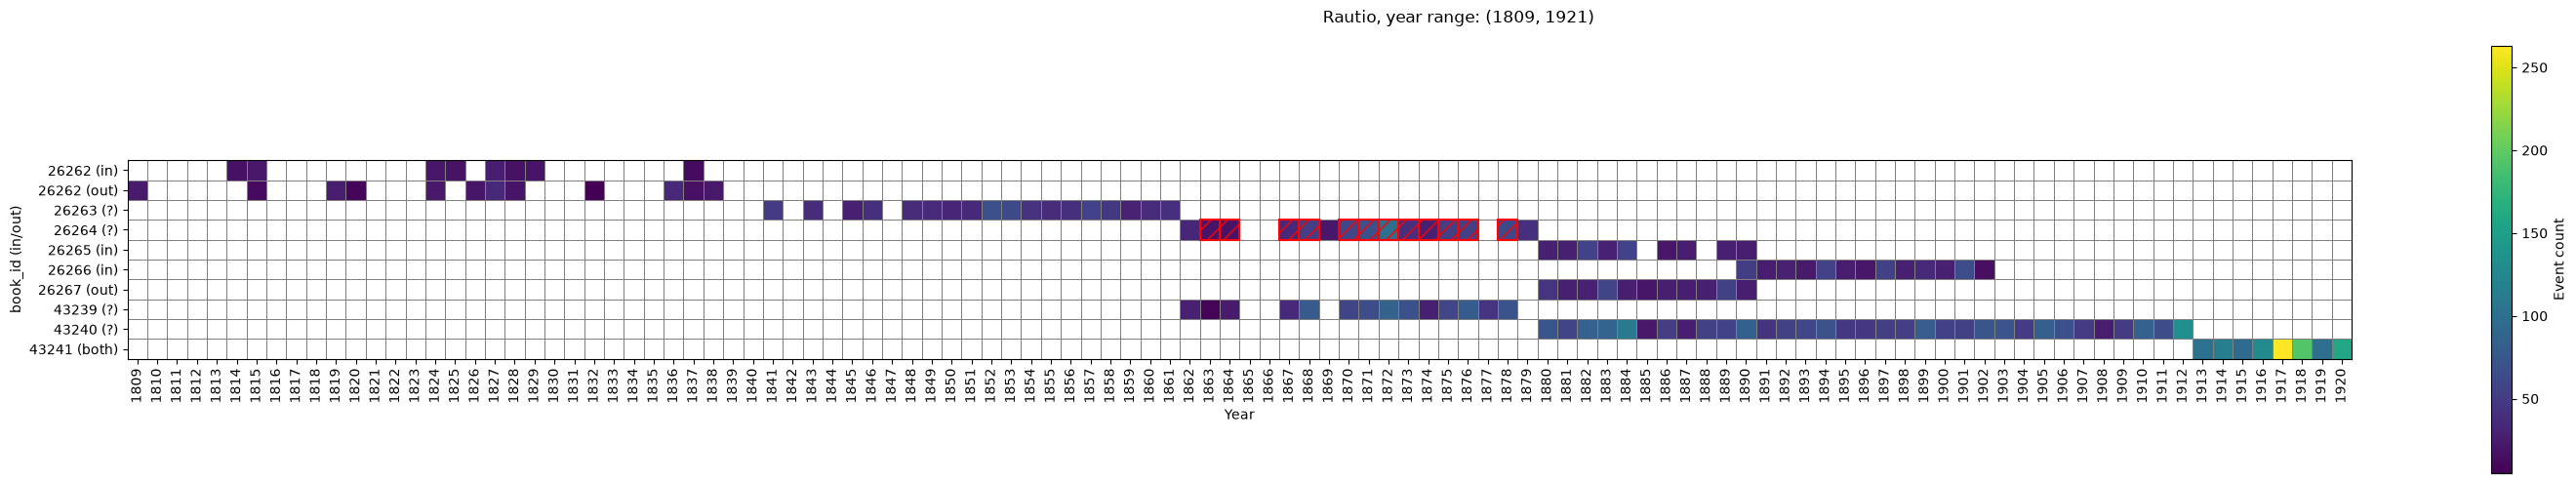

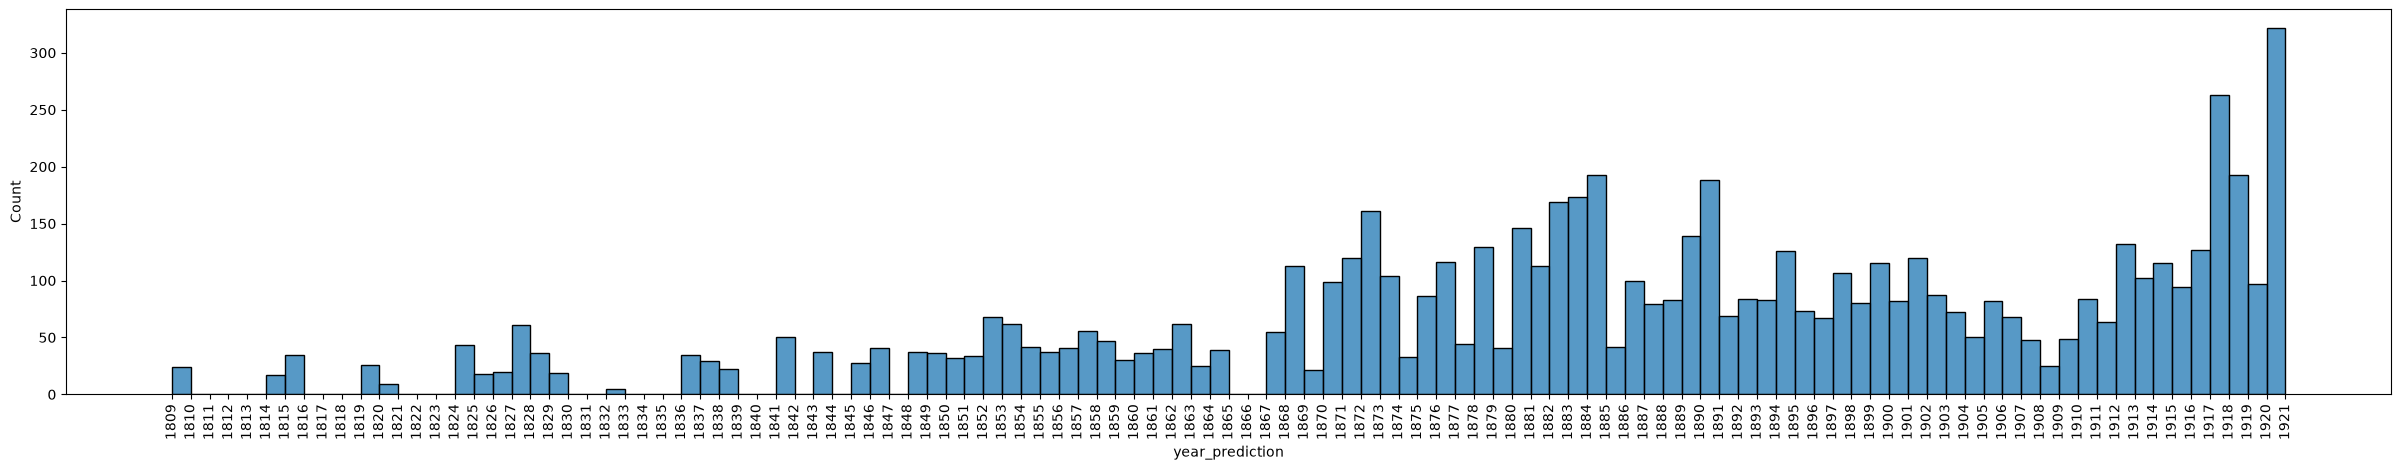

In [158]:
df_rautio = pd.read_json(
    f"outputs/json/all_migration_events_parish_splits_duplicate_info/447_migration_events.jsonl",
    lines=True
)
display(migration_duplicate_filtering_before_after_counts(df_rautio, (1809, 1921)))
fig, axs = plot_book_year_event_heatmap(df_rautio, "Rautio", (1809, 1921))
plot_non_duplicate_migration_histogram(df_rautio)
fig.tight_layout()

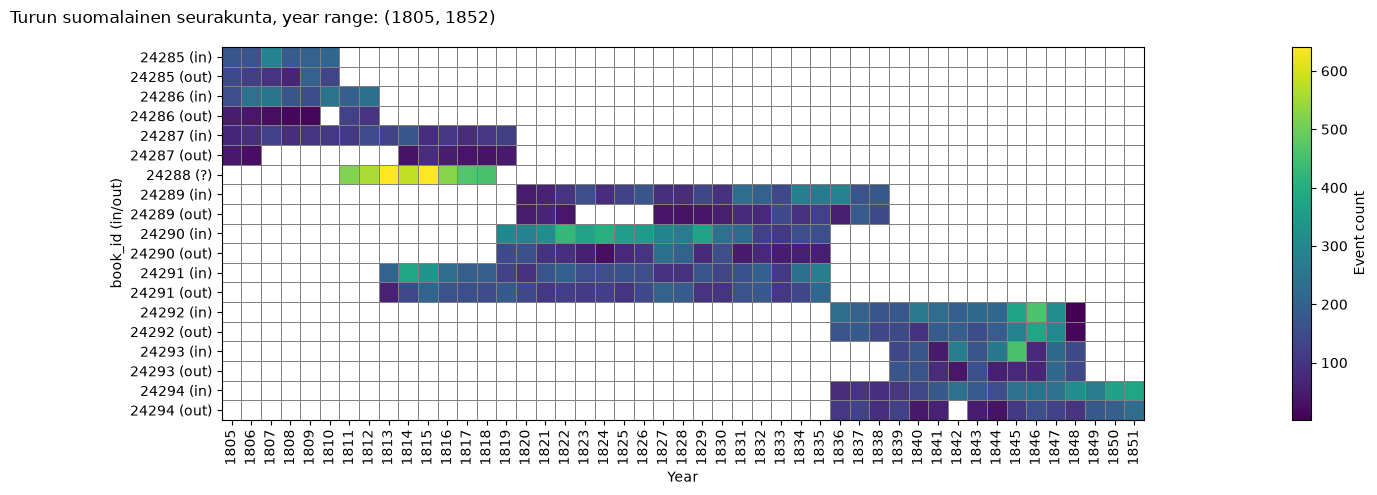

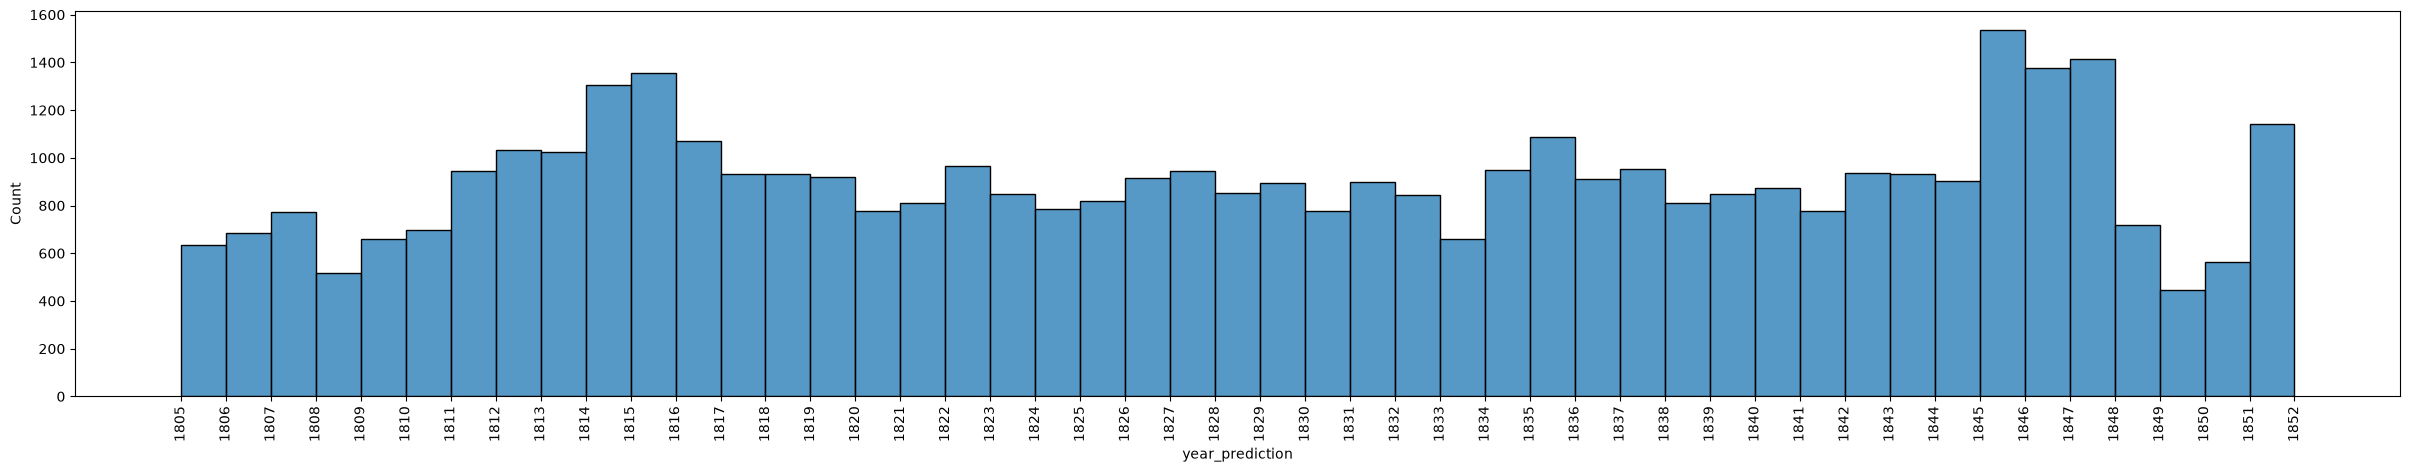

In [162]:
fig, axs = plot_book_year_event_heatmap(df_turun_suom, "Turun suomalainen seurakunta", (1805, 1852))
plot_non_duplicate_migration_histogram(df_turun_suom)
fig.tight_layout()

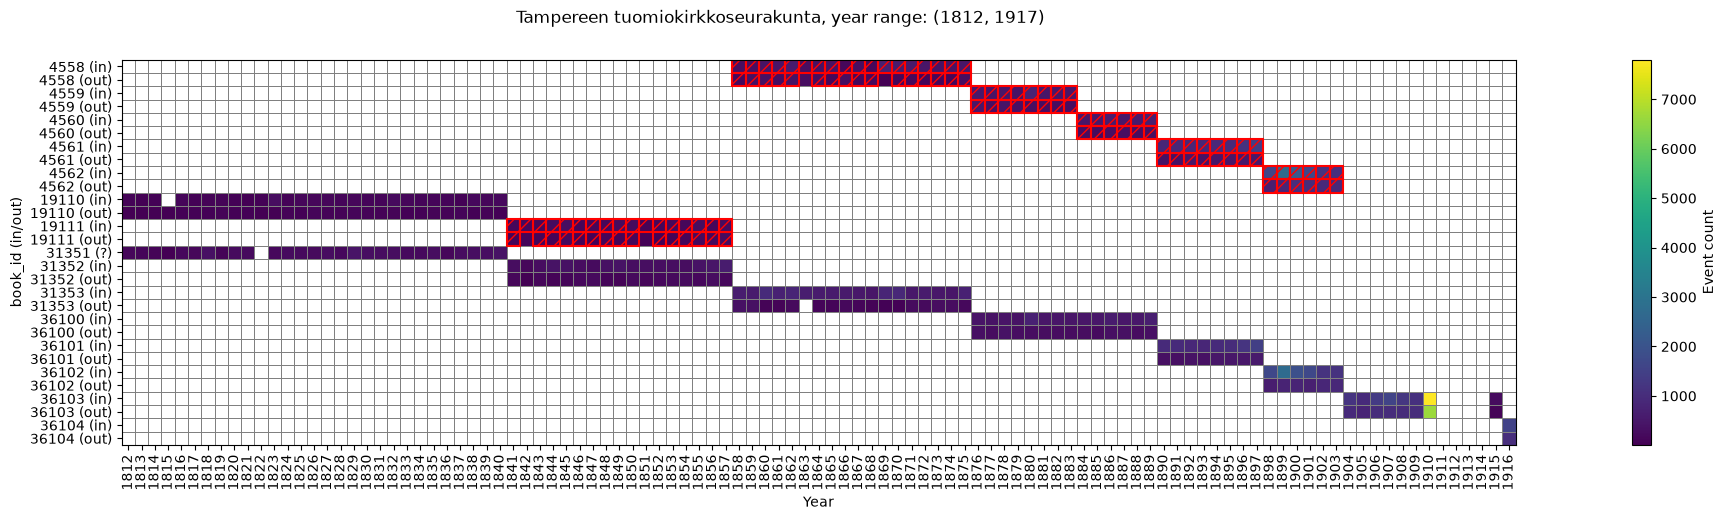

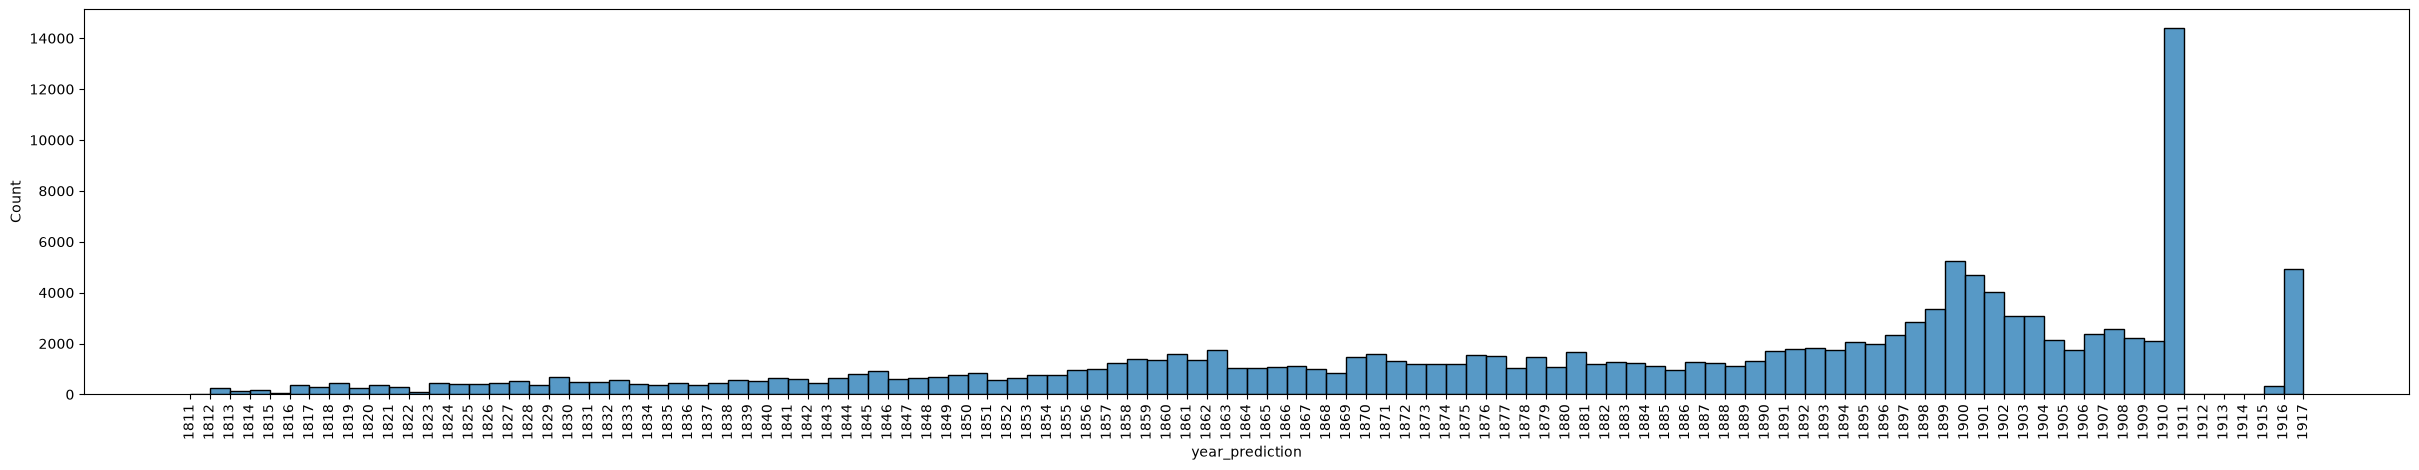

In [163]:
fig, axs = plot_book_year_event_heatmap(df_tampereen_tuom, "Tampereen tuomiokirkkoseurakunta", (1812, 1917))
plot_non_duplicate_migration_histogram(df_tampereen_tuom)

## Overall counts of events

In [166]:
from collections import defaultdict


total_non_duplicate_events = 0
non_duplicate_events_year_counts = defaultdict(int)
for file_path in Path("outputs/json/all_migration_events_parish_splits_duplicate_info").glob("*.jsonl"):
    with open(file_path, "r") as fp:
        for line in fp:
            if (
                ("duplicate\": false" in line)
                and (
                    ("in/out\": \"in" in line)
                    or
                    ("in/out\": \"out" in line)
                )
                and (
                    "year_prediction\": 0" not in line
                )
            ):
                total_non_duplicate_events += 1
                e = json.loads(line)
                non_duplicate_events_year_counts[e["year_prediction"]] += 1


f"Total non-duplicate events with clear direction and year prediction: {total_non_duplicate_events}"

'Total non-duplicate events with clear direction and year prediction: 3631700'

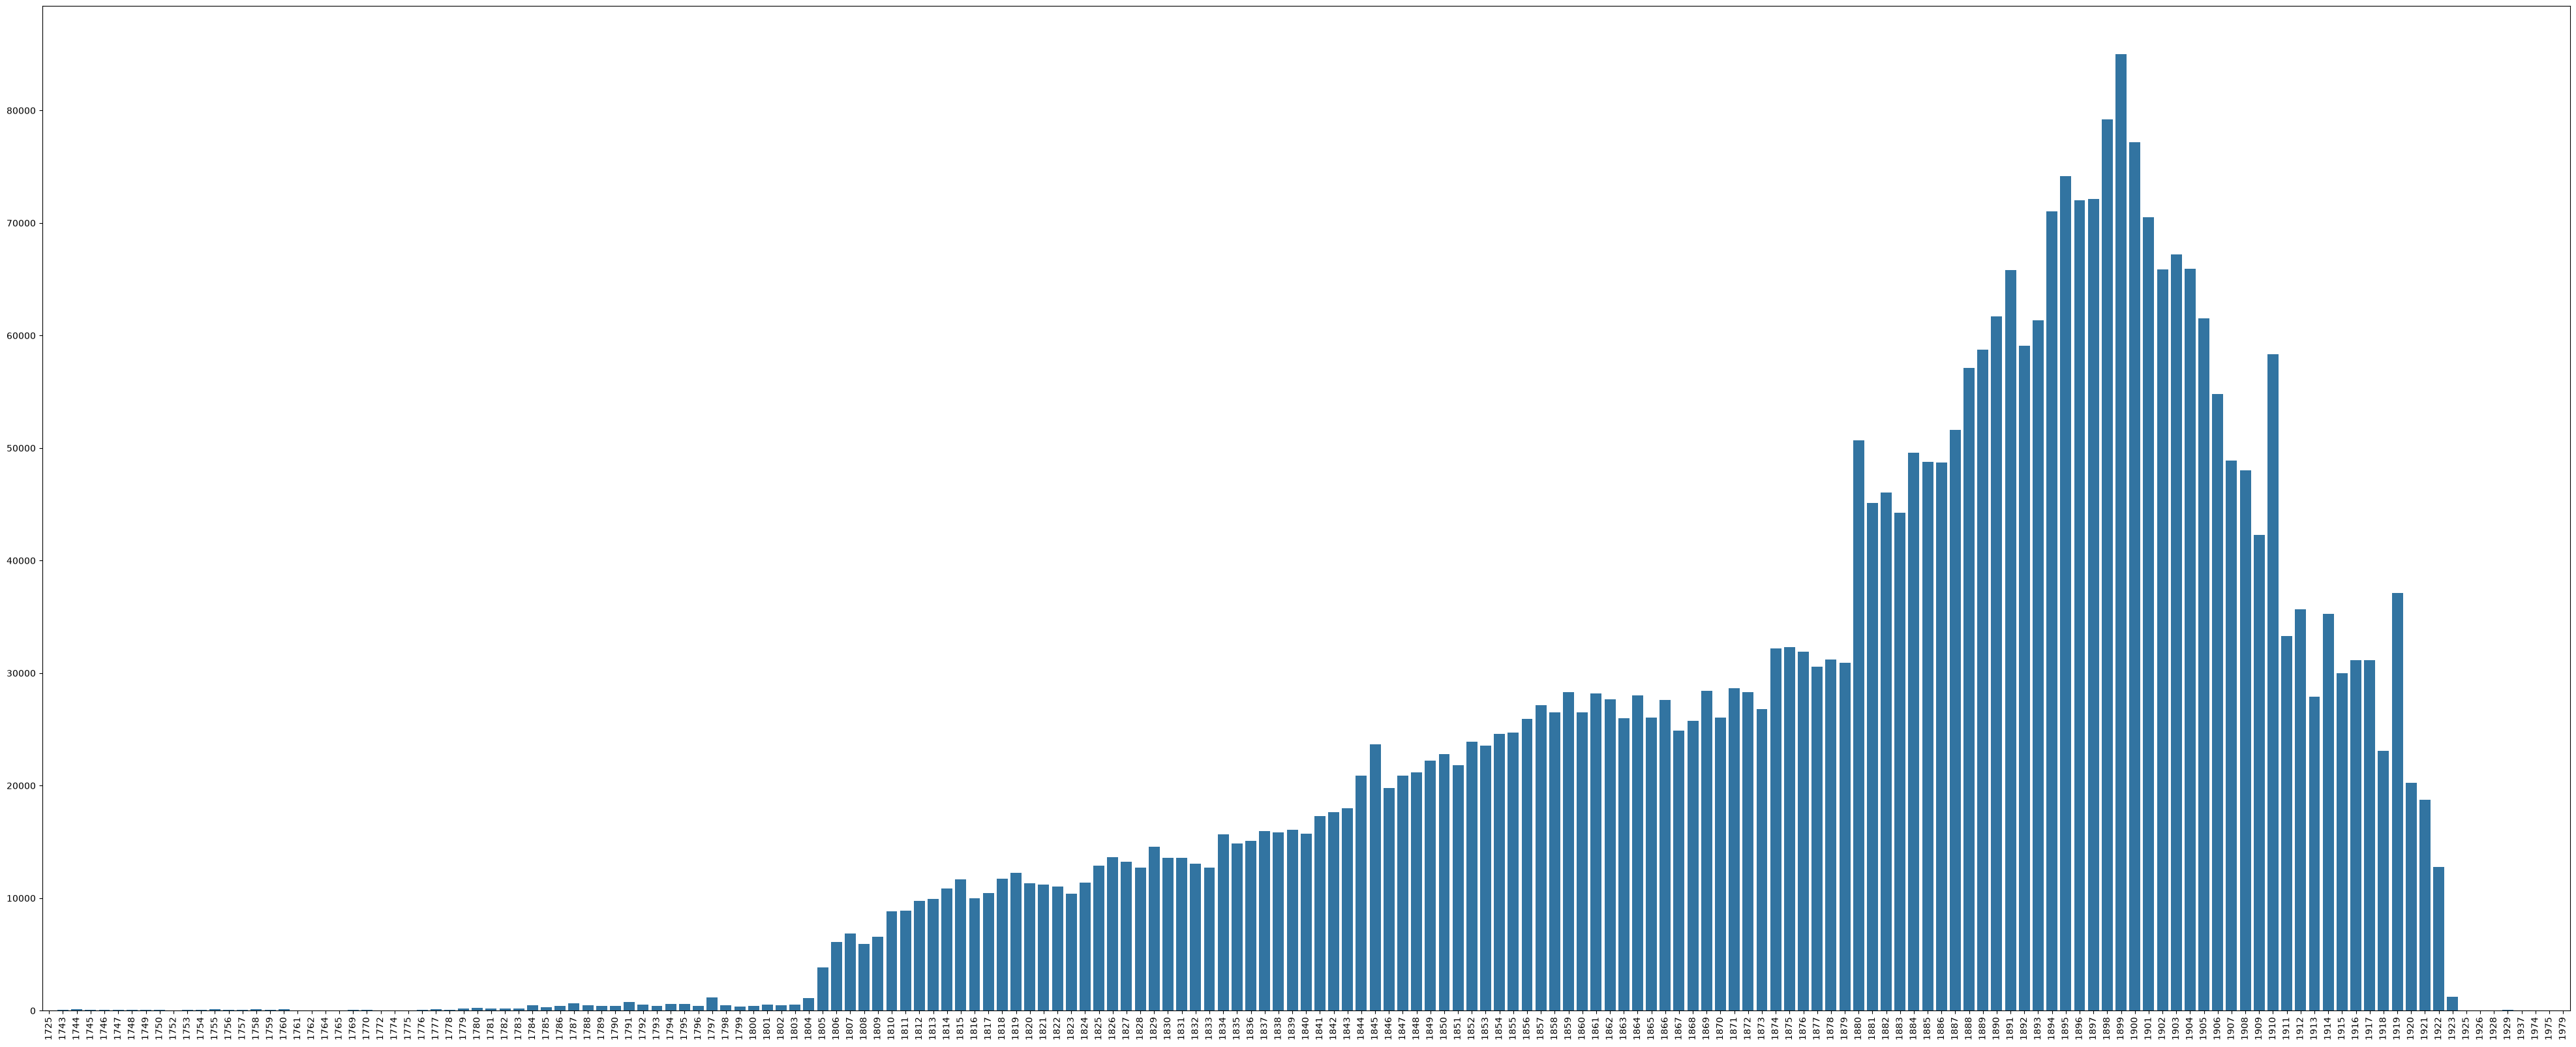

In [167]:
year_start = min(non_duplicate_events_year_counts.keys())
year_end = max(non_duplicate_events_year_counts.keys())

fig, axs = plt.subplots(figsize=(50, 20))
sns.barplot(
    x=tuple([x[0] for x in non_duplicate_events_year_counts.items()]),
    y=tuple([x[1] for x in non_duplicate_events_year_counts.items()])
)
axs.set_xticks(axs.get_xticks())
_ = axs.set_xticklabels(labels=sorted(non_duplicate_events_year_counts.keys()), rotation=90)